In [1]:
import torch

# This will intentionally crash the script if it accidentally loaded the CPU version
assert torch.cuda.is_available(), "CRITICAL ERROR: PyTorch cannot see the GPU! Check your kernel."

print(f"Environment is flawless! PyTorch is locked onto: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")

Environment is flawless! PyTorch is locked onto: NVIDIA A100 80GB PCIe
CUDA Version: 13.0


In [2]:
import pandas as pd
import torch.nn.functional as F
from transformers import AutoProcessor, DiffusionGemmaForBlockDiffusion
from tqdm import tqdm

# ==========================================
# 2. THE EXTRACTION FUNCTION
# ==========================================
def extract_diffusion_and_moe_metrics(prompt_text, model, tokenizer, canvas_size=256, diffusion_steps=48, architecture_name="DiffusionGemma-26B-MoE"):
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    prompt_len = inputs.input_ids.shape[1]
    
    vocab_size = len(tokenizer)
    canvas = torch.randint(0, vocab_size, (1, canvas_size), dtype=torch.long, device=model.device)
    current_input_ids = torch.cat([inputs.input_ids, canvas], dim=1)
    
    # --- PYTORCH FORWARD HOOK SETUP ---
    captured_router_logits = {}
    
    def get_router_hook():
        def hook(module, input, output):
            # FIX 1: The MoE router returns a tuple. We only want the first element (logits)
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output
            captured_router_logits['logits'] = logits.clone().detach()
        return hook

    # Dynamically find the LAST MoE router/gate in the network
    last_router_module = None
    for name, module in model.named_modules():
        if name.endswith('.gate') or name.endswith('.router'):
            last_router_module = module
            
    if last_router_module is None:
        raise ValueError("Could not find an MoE router/gate module in this model.")
        
    hook_handle = last_router_module.register_forward_hook(get_router_hook())
    
    # --- METRICS TRACKING ---
    records = []
    prev_step_entropy = {}   
    prev_step_predictions = {}
    
    try:
        with torch.no_grad():
            # FIX 2: TQDM Progress Bar
            for step_idx in tqdm(range(diffusion_steps), desc="Denoising Steps"):
                captured_router_logits.clear()
                
                outputs = model(current_input_ids, output_hidden_states=True)
                
                # --- A. DIFFUSION PREDICTION ENTROPY ---
                # FIX 3: The decoder ONLY outputs the canvas. No need to slice off the prompt.
                canvas_logits = outputs.logits[0] 
                
                probs_t = F.softmax(canvas_logits, dim=-1)
                log_probs_t = F.log_softmax(canvas_logits, dim=-1)
                entropy_t = -torch.sum(probs_t * log_probs_t, dim=-1) 
                top_confidence_t, top_token_ids_t = torch.max(probs_t, dim=-1)

                # --- B. MoE ROUTER ENTROPY (VIA HOOK) ---
                raw_router_logits = captured_router_logits['logits']
                num_experts = raw_router_logits.shape[-1]
                
                # FIX 4: The router is inside the decoder, so it only processes the 256 canvas tokens.
                final_layer_router_logits = raw_router_logits.view(canvas_size, num_experts)
                
                router_probs = F.softmax(final_layer_router_logits, dim=-1)
                router_log_probs = F.log_softmax(final_layer_router_logits, dim=-1)
                router_entropy = -torch.sum(router_probs * router_log_probs, dim=-1)
                
                # --- C. CPU OPTIMIZATION ---
                # FIX 5: Move tensors to CPU once per step to prevent bottlenecking the A100
                top_token_ids_cpu = top_token_ids_t.cpu().tolist()
                entropy_cpu = entropy_t.cpu().tolist()
                router_entropy_cpu = router_entropy.cpu().tolist()
                top_confidence_cpu = top_confidence_t.cpu().tolist()
                
                # Iterate over the EXACT 256 canvas tokens
                for i in range(canvas_size):
                    predicted_token_id = top_token_ids_cpu[i] 
                    current_entropy = entropy_cpu[i]
                    current_router_entropy = router_entropy_cpu[i]
                    
                    if step_idx > 0:
                        entropy_drop = prev_step_entropy[i] - current_entropy
                        token_changed = (predicted_token_id != prev_step_predictions[i])
                    else:
                        entropy_drop = 0.0 
                        token_changed = False 
                        
                    prev_step_entropy[i] = current_entropy
                    prev_step_predictions[i] = predicted_token_id 
                    
                    records.append({
                        "architecture": architecture_name,
                        "denoising_step": step_idx,
                        "canvas_position": i,
                        "prediction_entropy": current_entropy,
                        "router_entropy": current_router_entropy, 
                        "entropy_drop": entropy_drop,                 
                        "top_confidence": top_confidence_cpu[i],
                        "predicted_token": tokenizer.decode([predicted_token_id]),
                        "token_changed_from_prev_step": token_changed
                    })
                
                # Update the canvas for the next denoising step
                current_input_ids[0, prompt_len:] = top_token_ids_t

    finally:
        # CRITICAL: Always remove the hook to prevent memory leaks
        hook_handle.remove()

    return pd.DataFrame(records)


# ==========================================
# 3. EXECUTION SCRIPT
# ==========================================
if __name__ == "__main__":
    print("Loading Processor and Model...")
    processor = AutoProcessor.from_pretrained("google/diffusiongemma-26B-A4B-it")
    
    # We use device_map="cuda" and bfloat16 to fit it cleanly on the A100
    model = DiffusionGemmaForBlockDiffusion.from_pretrained(
        "google/diffusiongemma-26B-A4B-it", 
        device_map="cuda",
        torch_dtype=torch.bfloat16
    )

    # Define your prompt using the chat template
    messages = [
        {"role": "user", "content": [{"type": "text", "text": "Explain the concept of entropy in physics."}]}
    ]

    # Apply the chat template to get the raw formatted string (tokenize=False)
    print("Formatting prompt...")
    formatted_prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False
    )

    # Call the extraction function
    print("Starting extraction loop...")
    df = extract_diffusion_and_moe_metrics(
        prompt_text=formatted_prompt, 
        model=model, 
        tokenizer=processor.tokenizer, 
        canvas_size=256, 
        diffusion_steps=48
    )

    # Save your Week 8 deliverables
    output_filename = "diffusion_gemma_entropy_results.csv"
    df.to_csv(output_filename, index=False)
    print(f"\nExtraction complete! Data saved to {output_filename}")
    print("Shape of final dataset:", df.shape)

/home/shadeform/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Processor and Model...


Loading weights: 100%|██████████| 1047/1047 [00:09<00:00, 110.93it/s]


Formatting prompt...
Starting extraction loop...


Denoising Steps: 100%|██████████| 48/48 [00:14<00:00,  3.37it/s]


Extraction complete! Data saved to diffusion_gemma_entropy_results.csv
Shape of final dataset: (12288, 9)


In [3]:
import dill
dill.dump_session('notebook_env_8.db')


Loading dataset...


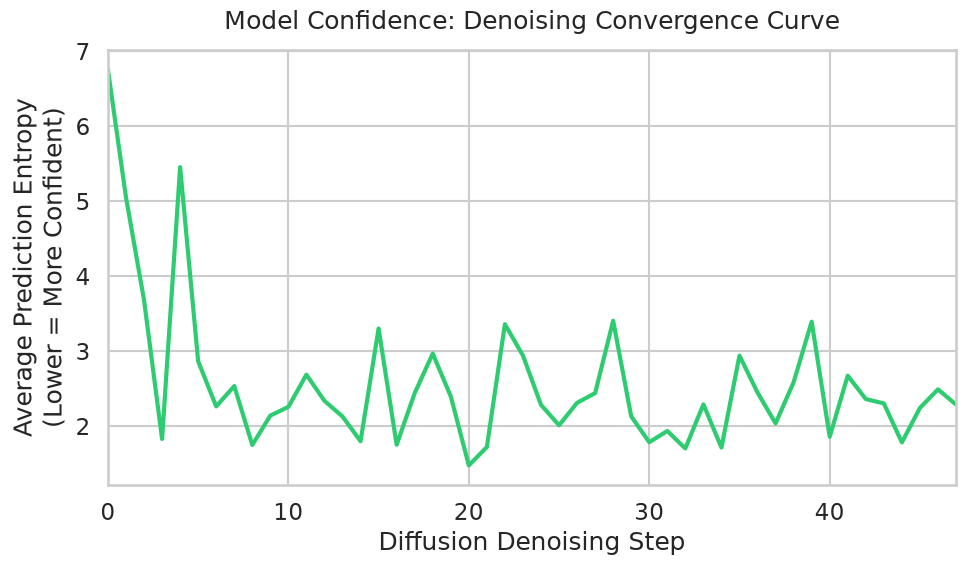

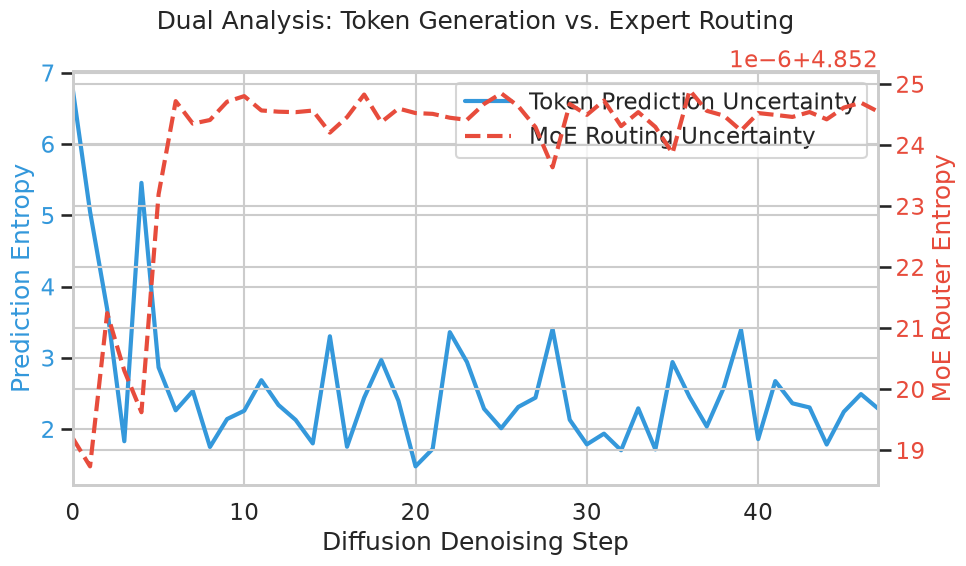

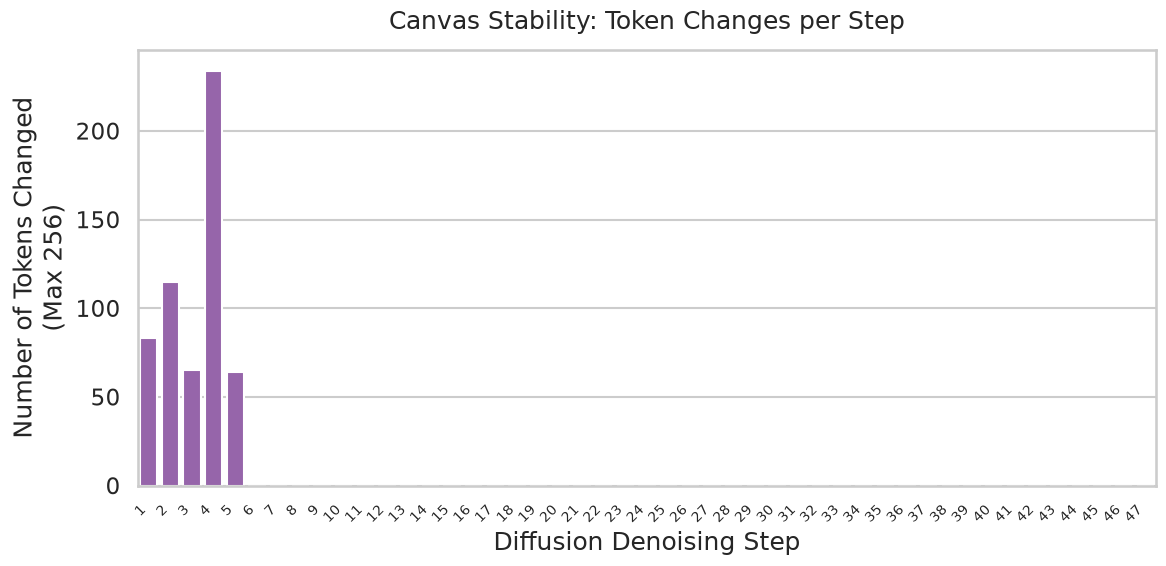


🎯 KEY METRICS FOR YOUR WEEK 8 REPORT
1. Overall Confidence Gain:
   - Starting Entropy (Step 0):  6.7560
   - Ending Entropy (Step 47):   2.2892
   - Total Entropy Drop:         4.4668

2. Largest Confidence Shift (The 'Aha!' Moment):
   - Occurred between Step 3 and Step 4
   - Entropy dropped by: 3.6250 in a single step

3. Canvas Freeze Point:
   - The canvas stabilized (less than 5 changes) at Step 6.
   - The model spent the remaining 41 steps just fine-tuning probabilities.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. Setup and Data Loading
# ==========================================
# Set global style for professional-looking charts
sns.set_theme(style="whitegrid", context="talk")

# Load your generated dataset
print("Loading dataset...")
df = pd.read_csv("diffusion_gemma_entropy_results.csv")

# ==========================================
# 1. The Denoising Convergence Curve
# ==========================================
# Group by step and calculate the average prediction entropy across the canvas
step_entropy = df.groupby('denoising_step')['prediction_entropy'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=step_entropy, x='denoising_step', y='prediction_entropy', linewidth=3, color="#2ecc71")
plt.title("Model Confidence: Denoising Convergence Curve", pad=15)
plt.xlabel("Diffusion Denoising Step")
plt.ylabel("Average Prediction Entropy\n(Lower = More Confident)")
plt.xlim(0, 47)
plt.tight_layout()
plt.savefig("1_convergence_curve.png", dpi=300)
plt.show()

# ==========================================
# 2. Router Entropy vs. Prediction Entropy 
# ==========================================
# Group by step and get both entropies
dual_metrics = df.groupby('denoising_step')[['prediction_entropy', 'router_entropy']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Prediction Entropy on primary Y-axis
color1 = "#3498db"
ax1.set_xlabel('Diffusion Denoising Step')
ax1.set_ylabel('Prediction Entropy', color=color1)
line1 = ax1.plot(dual_metrics['denoising_step'], dual_metrics['prediction_entropy'], color=color1, linewidth=3, label="Token Prediction Uncertainty")
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xlim(0, 47)

# Create a twin axis sharing the same X-axis
ax2 = ax1.twinx()  

# Plot Router Entropy on secondary Y-axis
color2 = "#e74c3c"
ax2.set_ylabel('MoE Router Entropy', color=color2)
line2 = ax2.plot(dual_metrics['denoising_step'], dual_metrics['router_entropy'], color=color2, linewidth=3, linestyle="--", label="MoE Routing Uncertainty")
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title("Dual Analysis: Token Generation vs. Expert Routing", pad=15)
plt.tight_layout()
plt.savefig("2_dual_entropy_analysis.png", dpi=300)
plt.show()

# ==========================================
# 3. The Canvas "Freeze" Point
# ==========================================
# Sum the number of changed tokens per step (remember step 0 is baseline so it has 0 changes)
token_changes = df.groupby('denoising_step')['token_changed_from_prev_step'].sum().reset_index()

plt.figure(figsize=(12, 6))
# We slice from step 1 onward because step 0 has no "previous step" to change from
sns.barplot(data=token_changes[1:], x='denoising_step', y='token_changed_from_prev_step', color="#9b59b6")
plt.title("Canvas Stability: Token Changes per Step", pad=15)
plt.xlabel("Diffusion Denoising Step")
plt.ylabel("Number of Tokens Changed\n(Max 256)")
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate X labels so they don't overlap
plt.tight_layout()
plt.savefig("3_canvas_freeze_point.png", dpi=300)
plt.show()

# ==========================================
# 4. Extracting Key Report Metrics
# ==========================================
print("\n" + "="*50)
print("🎯 KEY METRICS FOR YOUR WEEK 8 REPORT")
print("="*50)

# Start vs End Entropy
start_entropy = step_entropy.loc[0, 'prediction_entropy']
end_entropy = step_entropy.loc[47, 'prediction_entropy']
print(f"1. Overall Confidence Gain:")
print(f"   - Starting Entropy (Step 0):  {start_entropy:.4f}")
print(f"   - Ending Entropy (Step 47):   {end_entropy:.4f}")
print(f"   - Total Entropy Drop:         {start_entropy - end_entropy:.4f}\n")

# Maximum Entropy Drop (The "Aha!" Moment)
# Calculate the difference between consecutive steps
step_entropy['entropy_diff'] = step_entropy['prediction_entropy'].diff().abs()
max_drop_idx = step_entropy['entropy_diff'].idxmax()
max_drop_val = step_entropy['entropy_diff'].max()
print(f"2. Largest Confidence Shift (The 'Aha!' Moment):")
print(f"   - Occurred between Step {max_drop_idx-1} and Step {max_drop_idx}")
print(f"   - Entropy dropped by: {max_drop_val:.4f} in a single step\n")

# Freeze Point (When do tokens stop changing?)
# Find the first step where changes drop below 5 (meaning 98% of the canvas is locked)
threshold = 5
freeze_steps = token_changes[token_changes['token_changed_from_prev_step'] <= threshold]
if len(freeze_steps) > 1: # >1 because step 0 is always 0
    freeze_step = freeze_steps.iloc[1]['denoising_step']
    print(f"3. Canvas Freeze Point:")
    print(f"   - The canvas stabilized (less than {threshold} changes) at Step {freeze_step}.")
    print(f"   - The model spent the remaining {47 - freeze_step} steps just fine-tuning probabilities.")
else:
    print("3. Canvas Freeze Point:")
    print("   - The canvas never fully locked in. Tokens were still changing at Step 47!")
print("="*50)

In [5]:
from datasets import load_dataset

# Load the dataset using the official canonical namespace path
dataset = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="validation")

# Filter out empty lines and short headers to grab solid paragraphs
texts = [text for text in dataset['text'] if len(text.strip()) > 50]

# Join the first 5 solid paragraphs
sample_text = " ".join(texts[:5])
print(f"Sample length: {len(sample_text)} characters")
print(f"Preview:\n{sample_text[:200]}...")

Sample length: 2245 characters
Preview:
 Homarus gammarus , known as the European lobster or common lobster , is a species of clawed lobster from the eastern Atlantic Ocean , Mediterranean Sea and parts of the Black Sea . It is closely rela...


In [6]:
# 2. Define the prompt
messages = [
    {"role": "user", "content": [{"type": "text", "text": f"Continue the following text:\n\n{sample_text}"}]}
]

# 3. Apply the chat template
print("Formatting prompt...")
formatted_prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False
)

# 4. Call the extraction function 
# (It will automatically use your pre-loaded 'model' and 'processor')
print("Starting extraction loop...")
df = extract_diffusion_and_moe_metrics(
    prompt_text=formatted_prompt, 
    model=model, 
    tokenizer=processor.tokenizer, 
    canvas_size=256, 
    diffusion_steps=48
)

# 5. Save results
output_filename = "diffusion_gemma_wikitext_results.csv"
df.to_csv(output_filename, index=False)
print(f"\nExtraction complete! Data saved to {output_filename}")
print("Shape of final dataset:", df.shape)

Formatting prompt...
Starting extraction loop...


Denoising Steps: 100%|██████████| 48/48 [00:15<00:00,  3.08it/s]


Extraction complete! Data saved to diffusion_gemma_wikitext_results.csv
Shape of final dataset: (12288, 9)


Why did this happen? (The Core Bug)
The issue lies in how we are forcing the model to update its canvas. Diffusion LLMs (like DiffusionGemma) are fundamentally different from standard autoregressive models.

In standard models, it is normal to take the argmax (the most likely discrete word), convert it to an ID, and feed it back into the model. However, Diffusion models do not work with discrete IDs during the denoising steps. They denoise continuous latent embeddings.

By calculating top_token_ids_t and hard-updating the input with current_input_ids[0, prompt_len:] = top_token_ids_t, we shattered the continuous mathematical diffusion schedule. The model saw a wall of hard, discrete tokens when it was expecting noisy embeddings, panicked, and collapsed to predicting <eos>.

How to fix it for your report:
To get accurate entropy data without breaking the diffusion math, you cannot manually update current_input_ids in a simple for loop. You will need to either:

Use the model's native .generate() function and attach a PyTorch forward hook to capture the logits passively in the background as the model's internal scheduler handles the complex embedding math.

In [8]:
import torch
import pandas as pd
import torch.nn.functional as F
from transformers import AutoProcessor, DiffusionGemmaForBlockDiffusion
from datasets import load_dataset
from tqdm import tqdm

def extract_diffusion_metrics_via_hooks(prompt_text, model, tokenizer, canvas_size=256):
    """
    Passively observes a diffusion model by hooking into its forward passes 
    during native generation, preserving the continuous latent math.
    """
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    
    # 1. Setup Storage for our "Sensors"
    captured_data = {
        'prediction_logits': [],
        'router_logits': []
    }
    
    # 2. Define the Hooks
    def router_hook(module, args, output):
        # The MoE router often returns a tuple. We just want the logits.
        logits = output[0] if isinstance(output, tuple) else output
        # Instantly clone and move to CPU so we don't blow up the A100's VRAM
        captured_data['router_logits'].append(logits.clone().detach().cpu())
        
    def lm_head_hook(module, args, output):
        # Capture the final token prediction logits
        logits = output[0] if isinstance(output, tuple) else output
        captured_data['prediction_logits'].append(logits.clone().detach().cpu())
        
    # 3. Locate the Modules and Attach Hooks
    router_module = None
    # Find the LAST MoE router in the network
    for name, module in model.named_modules():
        if name.endswith('.gate') or name.endswith('.router'):
            router_module = module
            
    # Find the final language modeling head (output projection)
    lm_head_module = model.get_output_embeddings()
    if lm_head_module is None and hasattr(model, 'lm_head'):
        lm_head_module = model.lm_head
        
    if router_module is None or lm_head_module is None:
        raise ValueError("CRITICAL ERROR: Could not locate the MoE router or LM head.")
        
    h_router = router_module.register_forward_hook(router_hook)
    h_lm = lm_head_module.register_forward_hook(lm_head_hook)
    
    # 4. Execute Native Generation
    print("Running native model.generate()... (Letting the scheduler handle the math)")
    try:
        with torch.no_grad():
            _ = model.generate(
                **inputs,
                max_new_tokens=canvas_size
            )
    finally:
        # CRITICAL: Always remove hooks even if generation fails, to prevent memory leaks
        h_router.remove()
        h_lm.remove()
        
    # 5. Post-Process the Captured Data
    print(f"Generation complete! Captured {len(captured_data['prediction_logits'])} diffusion steps.")
    records = []
    num_steps = len(captured_data['prediction_logits'])
    
    prev_step_predictions = {}
    prev_step_entropy = {}
    
    # Process step-by-step
    for step_idx in tqdm(range(num_steps), desc="Processing Captured Steps"):
        p_logits = captured_data['prediction_logits'][step_idx]
        r_logits = captured_data['router_logits'][step_idx]
        
        # Ensure router logits match the sequence shape (batch, seq_len, experts)
        if r_logits.dim() == 2:
            r_logits = r_logits.view(p_logits.shape[0], p_logits.shape[1], -1)
            
        # Isolate the canvas (the newly generated tokens at the end of the sequence)
        # We slice the last `canvas_size` tokens out of the sequence
        canvas_p_logits = p_logits[0, -canvas_size:, :]
        canvas_r_logits = r_logits[0, -canvas_size:, :]
        
        # Calculate Prediction Entropy
        p_probs = F.softmax(canvas_p_logits, dim=-1)
        p_log_probs = F.log_softmax(canvas_p_logits, dim=-1)
        p_entropy = -torch.sum(p_probs * p_log_probs, dim=-1)
        p_conf, p_ids = torch.max(p_probs, dim=-1)
        
        # Calculate Router Entropy
        r_probs = F.softmax(canvas_r_logits, dim=-1)
        r_log_probs = F.log_softmax(canvas_r_logits, dim=-1)
        r_entropy = -torch.sum(r_probs * r_log_probs, dim=-1)
        
        # Convert to standard Python lists for fast iteration
        p_ids_list = p_ids.tolist()
        p_entropy_list = p_entropy.tolist()
        r_entropy_list = r_entropy.tolist()
        p_conf_list = p_conf.tolist()
        
        # Build the rows for the DataFrame
        for i in range(len(p_ids_list)):
            predicted_token_id = p_ids_list[i]
            current_entropy = p_entropy_list[i]
            
            if step_idx > 0:
                entropy_drop = prev_step_entropy[i] - current_entropy
                token_changed = (predicted_token_id != prev_step_predictions[i])
            else:
                entropy_drop = 0.0
                token_changed = False
                
            prev_step_entropy[i] = current_entropy
            prev_step_predictions[i] = predicted_token_id
            
            records.append({
                "denoising_step": step_idx,
                "canvas_position": i,
                "prediction_entropy": current_entropy,
                "router_entropy": r_entropy_list[i],
                "entropy_drop": entropy_drop,
                "top_confidence": p_conf_list[i],
                "predicted_token": tokenizer.decode([predicted_token_id]),
                "token_changed_from_prev_step": token_changed
            })
            
    return pd.DataFrame(records)

# ==========================================
# EXECUTION SCRIPT
# ==========================================
if __name__ == "__main__":
    # 1. Fetch WikiText-103 Sample
    
    # 2. Format Prompt
    messages = [
        {"role": "user", "content": [{"type": "text", "text": f"Continue the following text:\n\n{sample_text}"}]}
    ]
    formatted_prompt = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False
    )
    
    # 3. Extract!
    df = extract_diffusion_metrics_via_hooks(
        prompt_text=formatted_prompt, 
        model=model, 
        tokenizer=processor.tokenizer, 
        canvas_size=256
    )
    
    # 4. Save
    output_filename = "diffusion_gemma_wikitext_fixed_results.csv"
    df.to_csv(output_filename, index=False)
    print(f"\nExtraction complete! Safe continuous diffusion data saved to {output_filename}")

Running native model.generate()... (Letting the scheduler handle the math)
Generation complete! Captured 17 diffusion steps.


Processing Captured Steps: 100%|██████████| 17/17 [00:01<00:00,  9.93it/s]



Extraction complete! Safe continuous diffusion data saved to diffusion_gemma_wikitext_fixed_results.csv


Loading WikiText dataset results...
Generating Heatmap...


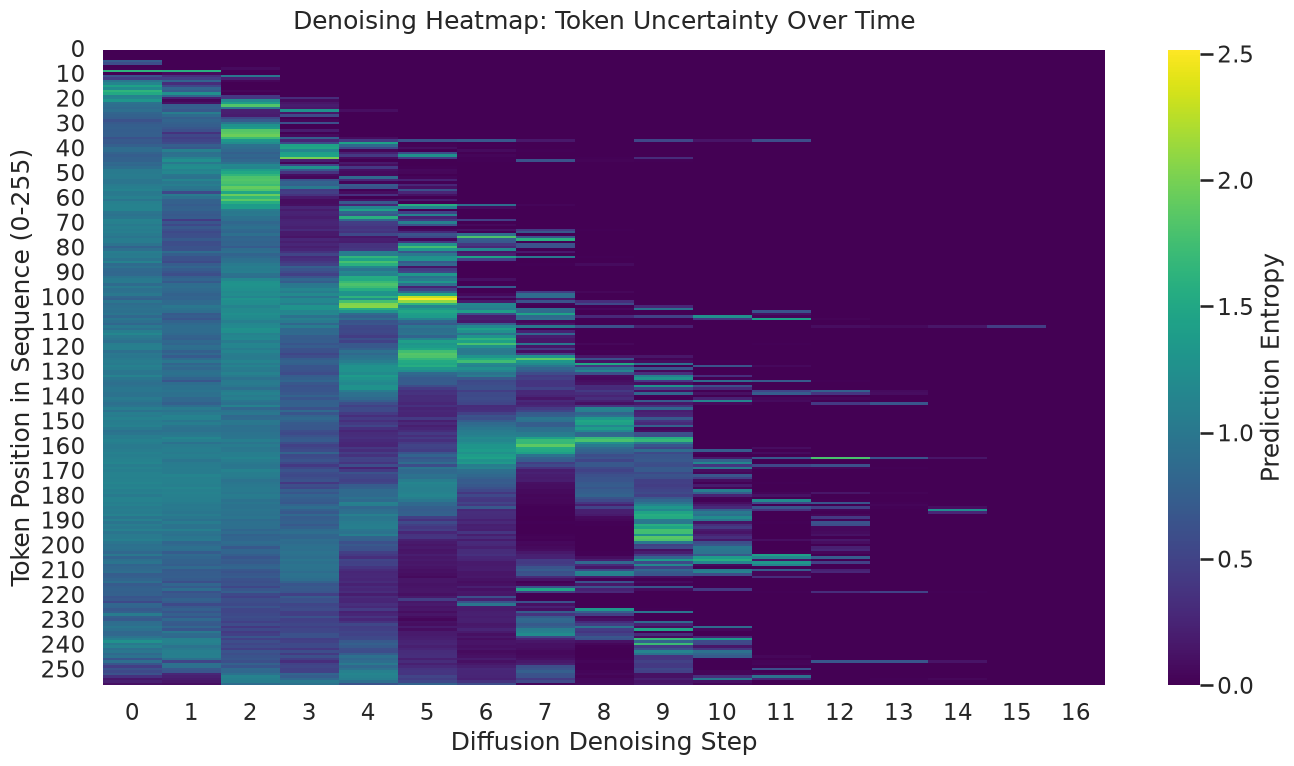

Generating 'Aha!' Moment Histogram...


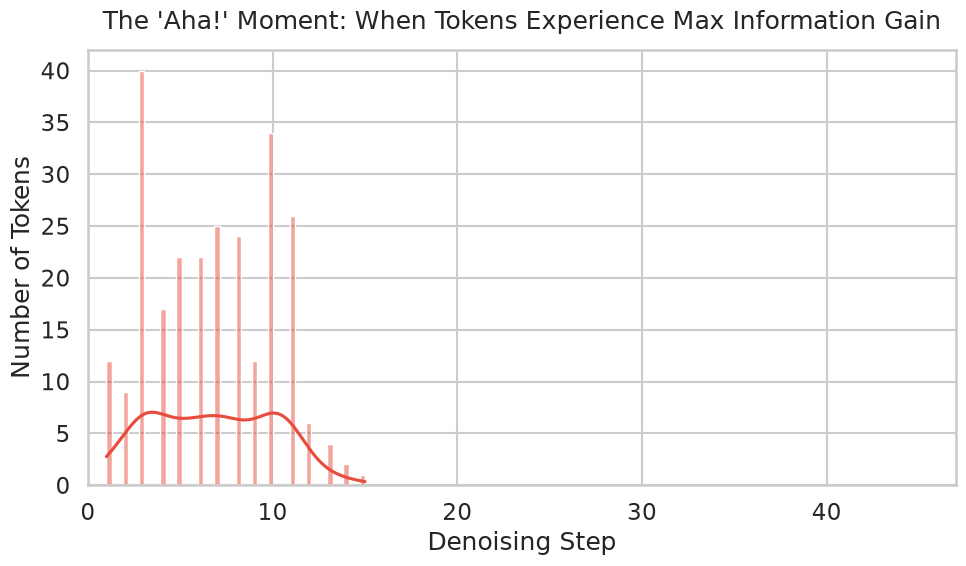

Generating Correlation Scatter Plot...


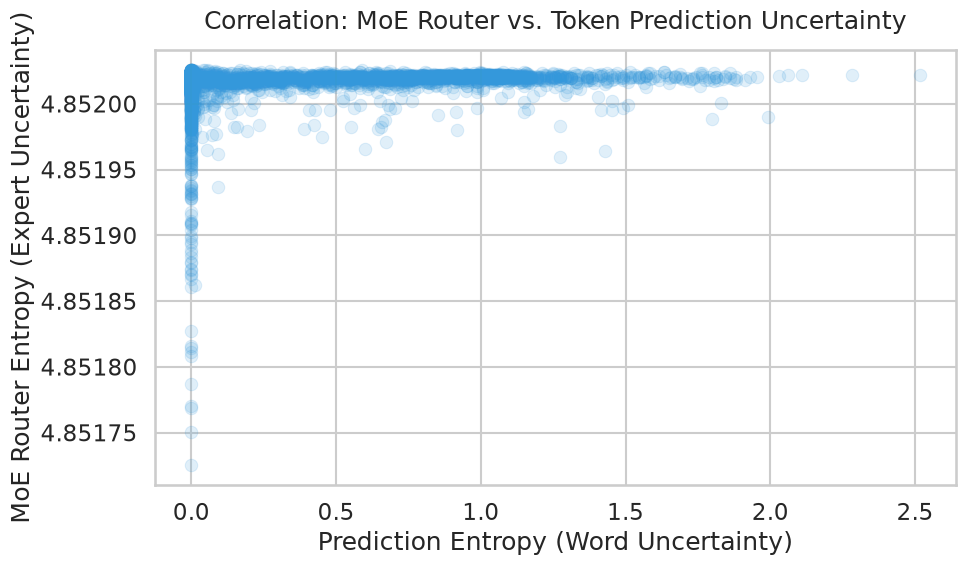

Generating Cumulative Freeze Curve...


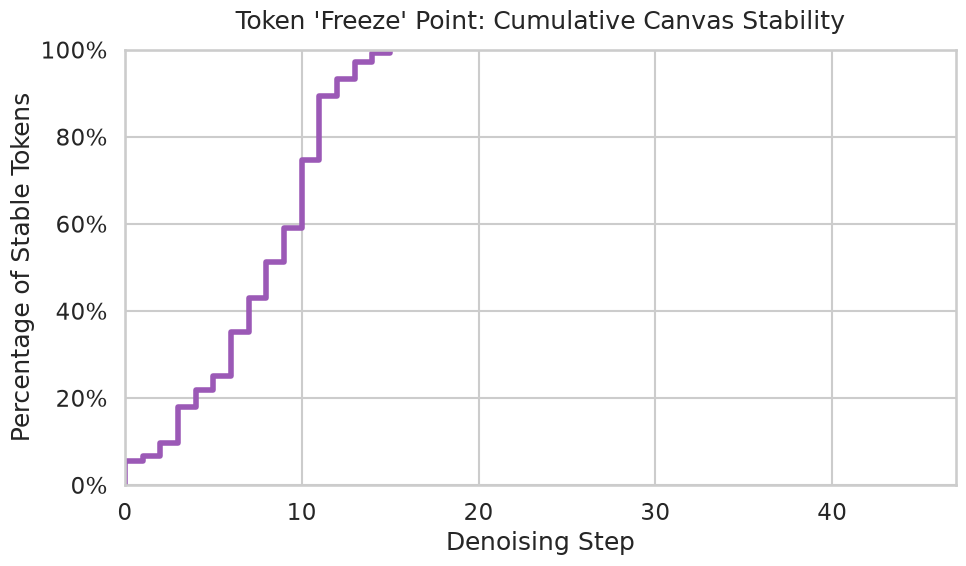


All charts generated successfully!


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 0. Setup and Data Loading
# ==========================================
# Set global style for professional-looking charts
sns.set_theme(style="whitegrid", context="talk")

print("Loading WikiText dataset results...")
df = pd.read_csv("diffusion_gemma_wikitext_fixed_results.csv")

# ==========================================
# 1. The Denoising Heatmap
# ==========================================
print("Generating Heatmap...")
plt.figure(figsize=(14, 8))
# Pivot data so rows are tokens, columns are steps, and values are entropy
heatmap_data = df.pivot(index='canvas_position', columns='denoising_step', values='prediction_entropy')

# Plot the heatmap using the 'viridis' color map (dark = low entropy/confident, bright = high entropy/confused)
sns.heatmap(heatmap_data, cmap="viridis", cbar_kws={'label': 'Prediction Entropy'})
plt.title("Denoising Heatmap: Token Uncertainty Over Time", pad=15)
plt.xlabel("Diffusion Denoising Step")
plt.ylabel("Token Position in Sequence (0-255)")
plt.tight_layout()
plt.savefig("wikitext_1_heatmap.png", dpi=300)
plt.show()

# ==========================================
# 2. The "Aha!" Moment Histogram
# ==========================================
print("Generating 'Aha!' Moment Histogram...")
plt.figure(figsize=(10, 6))

# For each token position, find the row (step) where it experienced its largest entropy drop
max_drop_idx = df.groupby('canvas_position')['entropy_drop'].idxmax()
max_drop_steps = df.loc[max_drop_idx]

sns.histplot(data=max_drop_steps, x='denoising_step', bins=48, color="#e74c3c", kde=True)
plt.title("The 'Aha!' Moment: When Tokens Experience Max Information Gain", pad=15)
plt.xlabel("Denoising Step")
plt.ylabel("Number of Tokens")
plt.xlim(0, 47)
plt.tight_layout()
plt.savefig("wikitext_2_aha_moment.png", dpi=300)
plt.show()

# ==========================================
# 3. Router vs. Prediction Correlation
# ==========================================
print("Generating Correlation Scatter Plot...")
plt.figure(figsize=(10, 6))

# We use a low alpha (transparency) because plotting 12,000+ points can get dense
sns.scatterplot(data=df, x='prediction_entropy', y='router_entropy', alpha=0.15, color="#3498db", edgecolor=None)
plt.title("Correlation: MoE Router vs. Token Prediction Uncertainty", pad=15)
plt.xlabel("Prediction Entropy (Word Uncertainty)")
plt.ylabel("MoE Router Entropy (Expert Uncertainty)")
plt.tight_layout()
plt.savefig("wikitext_3_scatter.png", dpi=300)
plt.show()

# ==========================================
# 4. The Token "Freeze" Cumulative Curve
# ==========================================
print("Generating Cumulative Freeze Curve...")
plt.figure(figsize=(10, 6))

# Find the LAST step where each token changed. After this step, the token is permanently "frozen".
last_change_steps = df[df['token_changed_from_prev_step'] == True].groupby('canvas_position')['denoising_step'].max()

# If a token never changed, it froze at step 0
all_freeze_steps = pd.Series(index=range(256), dtype=float).fillna(0)
all_freeze_steps.update(last_change_steps)

# Plot the cumulative distribution of when tokens lock in
sns.ecdfplot(data=all_freeze_steps, color="#9b59b6", linewidth=4)
plt.title("Token 'Freeze' Point: Cumulative Canvas Stability", pad=15)
plt.xlabel("Denoising Step")
plt.ylabel("Percentage of Stable Tokens")
plt.xlim(0, 47)
# Format the Y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.tight_layout()
plt.savefig("wikitext_4_cumulative_freeze.png", dpi=300)
plt.show()

print("\nAll charts generated successfully!")

In [10]:
def extract_diffusion_metrics_with_correctness(prompt_text, ground_truth_text, model, tokenizer, canvas_size=256):
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    
    # --- NEW: Process Ground Truth ---
    # Tokenize the actual true continuation text so we can grade the model
    gt_inputs = tokenizer(ground_truth_text, return_tensors="pt", add_special_tokens=False)
    ground_truth_ids = gt_inputs.input_ids[0].tolist()
    
    # Pad or truncate the ground truth to exactly match our canvas size
    if len(ground_truth_ids) >= canvas_size:
        ground_truth_ids = ground_truth_ids[:canvas_size]
    else:
        # Pad with EOS tokens if the ground truth is shorter than the canvas
        ground_truth_ids += [tokenizer.eos_token_id] * (canvas_size - len(ground_truth_ids))
        
    # 1. Setup Storage for our "Sensors"
    captured_data = {
        'prediction_logits': [],
        'router_logits': []
    }
    
    # 2. Define the Hooks
    def router_hook(module, args, output):
        logits = output[0] if isinstance(output, tuple) else output
        captured_data['router_logits'].append(logits.clone().detach().cpu())
        
    def lm_head_hook(module, args, output):
        logits = output[0] if isinstance(output, tuple) else output
        captured_data['prediction_logits'].append(logits.clone().detach().cpu())
        
    # 3. Locate Modules and Attach Hooks
    router_module = None
    for name, module in model.named_modules():
        if name.endswith('.gate') or name.endswith('.router'):
            router_module = module
            
    lm_head_module = model.get_output_embeddings()
    if lm_head_module is None and hasattr(model, 'lm_head'):
        lm_head_module = model.lm_head
        
    h_router = router_module.register_forward_hook(router_hook)
    h_lm = lm_head_module.register_forward_hook(lm_head_hook)
    
    # 4. Execute Native Generation
    print("Running native model.generate()...")
    try:
        with torch.no_grad():
            _ = model.generate(**inputs, max_new_tokens=canvas_size)
    finally:
        h_router.remove()
        h_lm.remove()
        
    # 5. Post-Process Data
    print(f"Generation complete! Processing steps...")
    records = []
    num_steps = len(captured_data['prediction_logits'])
    
    prev_step_predictions = {}
    prev_step_entropy = {}
    
    for step_idx in tqdm(range(num_steps), desc="Processing Captured Steps"):
        p_logits = captured_data['prediction_logits'][step_idx]
        r_logits = captured_data['router_logits'][step_idx]
        
        if r_logits.dim() == 2:
            r_logits = r_logits.view(p_logits.shape[0], p_logits.shape[1], -1)
            
        canvas_p_logits = p_logits[0, -canvas_size:, :]
        canvas_r_logits = r_logits[0, -canvas_size:, :]
        
        p_probs = F.softmax(canvas_p_logits, dim=-1)
        p_log_probs = F.log_softmax(canvas_p_logits, dim=-1)
        p_entropy = -torch.sum(p_probs * p_log_probs, dim=-1)
        p_conf, p_ids = torch.max(p_probs, dim=-1)
        
        r_probs = F.softmax(canvas_r_logits, dim=-1)
        r_log_probs = F.log_softmax(canvas_r_logits, dim=-1)
        r_entropy = -torch.sum(r_probs * r_log_probs, dim=-1)
        
        p_ids_list = p_ids.tolist()
        p_entropy_list = p_entropy.tolist()
        r_entropy_list = r_entropy.tolist()
        p_conf_list = p_conf.tolist()
        
        for i in range(len(p_ids_list)):
            predicted_token_id = p_ids_list[i]
            current_entropy = p_entropy_list[i]
            true_token_id = ground_truth_ids[i]  # Fetch the real WikiText token
            
            if step_idx > 0:
                entropy_drop = prev_step_entropy[i] - current_entropy
                token_changed = (predicted_token_id != prev_step_predictions[i])
            else:
                entropy_drop = 0.0
                token_changed = False
                
            prev_step_entropy[i] = current_entropy
            prev_step_predictions[i] = predicted_token_id
            
            records.append({
                "denoising_step": step_idx,
                "canvas_position": i,
                "prediction_entropy": current_entropy,
                "router_entropy": r_entropy_list[i],
                "entropy_drop": entropy_drop,
                "top_confidence": p_conf_list[i],
                "predicted_token": tokenizer.decode([predicted_token_id]),
                "true_token": tokenizer.decode([true_token_id]), # --- NEW: Text of true token ---
                "token_changed_from_prev_step": token_changed,
                "is_correct": bool(predicted_token_id == true_token_id) # --- NEW: Correctness Check ---
            })
            
    return pd.DataFrame(records)

# ==========================================
# EXECUTION SCRIPT
# ==========================================
if __name__ == "__main__":
    print("\nFetching WikiText-103 Dataset...")
    dataset = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="validation")
    texts = [text for text in dataset['text'] if len(text.strip()) > 50]
    
    # We use paragraph 0 as the prompt, and paragraph 1 as the expected generation
    sample_text = texts[0].strip()
    target_continuation = texts[1].strip()
    
    messages = [
        {"role": "user", "content": [{"type": "text", "text": f"Continue the following text:\n\n{sample_text}"}]}
    ]
    formatted_prompt = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False
    )
    
    # Pass BOTH the prompt and the target text to the function
    df = extract_diffusion_metrics_with_correctness(
        prompt_text=formatted_prompt, 
        ground_truth_text=target_continuation, 
        model=model, 
        tokenizer=processor.tokenizer, 
        canvas_size=256
    )
    
    output_filename = "diffusion_gemma_wikitext_correctness_results.csv"
    df.to_csv(output_filename, index=False)
    print(f"\nExtraction complete! Data saved to {output_filename}")


Fetching WikiText-103 Dataset...
Running native model.generate()...
Generation complete! Processing steps...


Processing Captured Steps: 100%|██████████| 18/18 [00:01<00:00,  9.52it/s]



Extraction complete! Data saved to diffusion_gemma_wikitext_correctness_results.csv


Loading correctness dataset...
Generating Entropy Decay Line Chart...


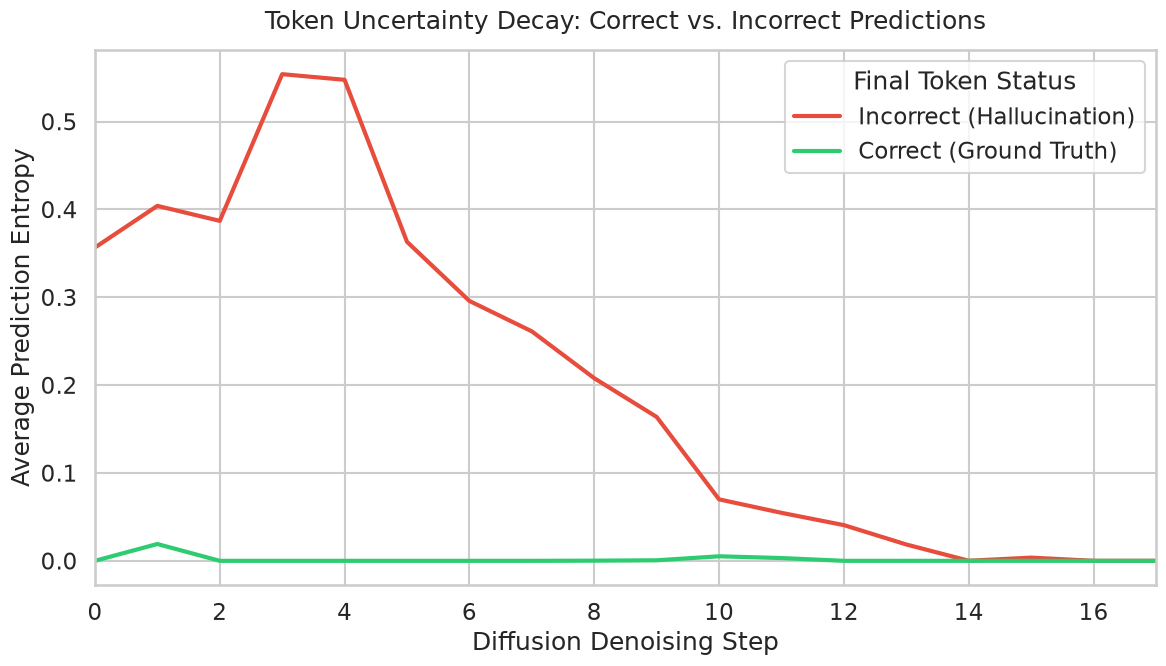

Generating Final Step Boxplot...


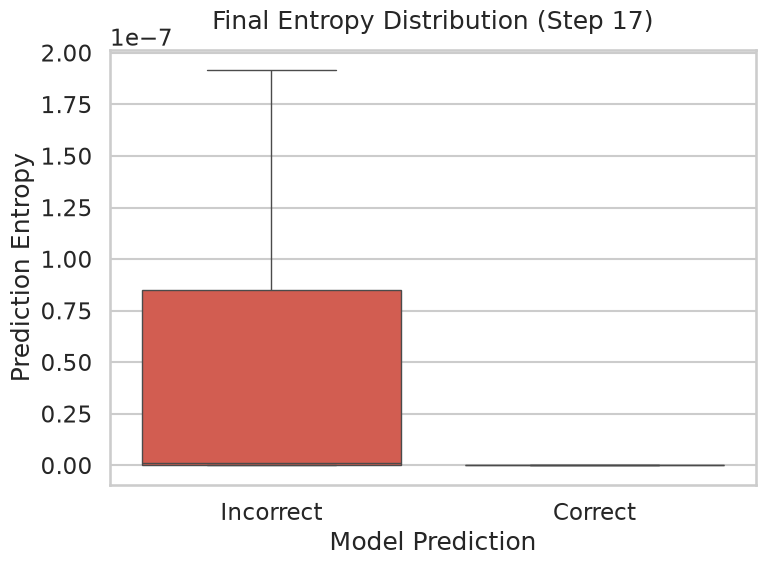

In [11]:
# ==========================================
# 0. Setup and Data Loading
# ==========================================
# Set global style for professional-looking charts
sns.set_theme(style="whitegrid", context="talk")

print("Loading correctness dataset...")
df = pd.read_csv("diffusion_gemma_wikitext_correctness_results.csv")

# Custom colors: Green for Correct, Red for Incorrect
custom_palette = {True: "#2ecc71", False: "#e74c3c"}

# ==========================================
# 1. Entropy Decay: Correct vs. Incorrect
# ==========================================
print("Generating Entropy Decay Line Chart...")
plt.figure(figsize=(12, 7))

# Plot the average entropy over time, split by whether the token was correct
sns.lineplot(
    data=df, 
    x='denoising_step', 
    y='prediction_entropy', 
    hue='is_correct', 
    palette=custom_palette, 
    linewidth=3,
    errorbar=None # Removes the messy shadow intervals for a clean look
)

plt.title("Token Uncertainty Decay: Correct vs. Incorrect Predictions", pad=15)
plt.xlabel("Diffusion Denoising Step")
plt.ylabel("Average Prediction Entropy")
plt.xlim(0, df['denoising_step'].max())

# Update the legend to be readable
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Incorrect (Hallucination)", "Correct (Ground Truth)"], title="Final Token Status")

plt.tight_layout()
plt.savefig("wikitext_5_correctness_decay.png", dpi=300)
plt.show()

# ==========================================
# 2. Final Step Entropy Distribution (Boxplot)
# ==========================================
print("Generating Final Step Boxplot...")
final_step = df['denoising_step'].max()
df_final = df[df['denoising_step'] == final_step]

plt.figure(figsize=(8, 6))

# Updated palette to catch both Python booleans and string representations
custom_palette = {True: "#2ecc71", False: "#e74c3c", "True": "#2ecc71", "False": "#e74c3c"}

sns.boxplot(
    data=df_final, 
    x='is_correct', 
    y='prediction_entropy', 
    hue='is_correct',        # NEW: Fixes the Seaborn deprecation warning
    palette=custom_palette,
    showfliers=False,
    legend=False             # NEW: Hides the redundant legend
)

plt.title(f"Final Entropy Distribution (Step {final_step})", pad=15)
plt.xlabel("Model Prediction")
plt.ylabel("Prediction Entropy")
plt.xticks(ticks=[0, 1], labels=["Incorrect", "Correct"])

plt.tight_layout()
plt.savefig("wikitext_6_final_distribution.png", dpi=300)
plt.show()